In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("all_matches.csv")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Scotland,False


In [4]:
pd.unique(df[['home_team','away_team']].values.ravel())

array(['Scotland', 'England', 'Wales', 'Ireland', 'Uruguay', 'Argentina',
       'Austria', 'Hungary', 'Bohemia', 'Belgium', 'France',
       'Switzerland', 'Netherlands', 'British Guiana',
       'Trinidad and Tobago', 'South Africa', 'Germany', 'Sweden',
       'Norway', 'Denmark', 'Italy', 'Chile', 'Finland', 'Luxembourg',
       'Russia', 'Philippines', 'China', 'Brazil', 'Suriname',
       'United States', 'Japan', 'Paraguay', 'Egypt', 'Greece', 'Spain',
       'Czechoslovakia', 'Yugoslavia', 'Estonia', 'Northern Ireland',
       'Costa Rica', 'El Salvador', 'Guatemala', 'Honduras', 'Poland',
       'Portugal', 'Romania', 'New Zealand', 'Australia', 'Latvia',
       'Mexico', 'Lithuania', 'Turkey', 'Aruba', 'Curaçao', 'Bulgaria',
       'Canada', 'Soviet Union', 'Haiti', 'Jamaica', 'Kenya', 'Uganda',
       'Bolivia', 'Azerbaijan', 'Armenia', 'Georgia', 'Peru',
       'British Honduras', 'Dutch East Indies', 'Barbados', 'Nicaragua',
       'Cuba', 'Faroe Islands', 'Iceland', 'Mart

In [5]:
from Confederations import get_confederation

all_teams = pd.unique(df[['home_team', 'away_team']].values.ravel())
unknowns = [t for t in all_teams if get_confederation(t) == "Unknown"]
print(sorted(unknowns))

[]


In [6]:
def get_tournament_weight(tournament, home_team, away_team):
    t = tournament.strip()
    home_conf = get_confederation(home_team)
    away_conf = get_confederation(away_team)
    conf_priority = ["UEFA", "CONMEBOL", "CONCACAF", "CAF", "AFC", "OFC", "Unknown"]
    home_rank = conf_priority.index(home_conf)
    away_rank = conf_priority.index(away_conf)
    top_conf = home_conf if home_rank <= away_rank else away_conf

    # ── Tier 4.0 ──────────────────────────────────────────
    if t == "World Cup":
        return 4.0

    # ── Tier 3.0 ──────────────────────────────────────────
    if t in ["European Championship", "Copa America", "Copa América"]:
        return 3.0

    # ── Tier 2.5 ──────────────────────────────────────────
    if t in ["European Championship qual",
             "Copa America qualifier", "Copa América qualifier",
             "African Nations Cup", "Confederations Cup", "Olympic Games","Euro Ch q & Nordic Ch","Euro Ch q & British Ch","South American Champ","Mundialito"]:
        return 2.5

    if "European Nations League" in t and "CONCACAF" not in t:
        if "A" in t: return 2.5
        elif "B" in t: return 2.0
        elif "C" in t: return 1.75
        elif "D" in t: return 1.5
        else: return 2.5

    # ── Tier 2.0 ──────────────────────────────────────────
    if t == "World Cup qualifier":
        if top_conf in ["UEFA", "CONMEBOL"]: return 2.0
        elif top_conf == "CAF":              return 1.75
        elif top_conf == "CONCACAF":         return 1.75
        elif top_conf == "AFC":              return 1.5
        else:                                return 1.25  # OFC

    if t in ["African Nations Cup qualifier",
             "World Cup q & Nordic Ch", "World Cup q & British Ch",
             "NA Champ & WC qual", "World Cup and CONCACAF Ch q",
             "World Cup and Asian Cup qual", "World Cup and African Cup qual",
             "WC and Oce Cup q", "WC q and Oce Cup"]:
        return 2.0

    # ── Tier 1.75 ─────────────────────────────────────────
    if t in ["CONCACAF Championship", "Asian Cup",
             "CONCACAF Cup", "CONCACAF Series","Intercontinental Champ"]:
        return 1.75

    if "CONCACAF Nations League" in t:
        if "A" in t: return 1.75
        elif "B" in t: return 1.5
        elif "C" in t: return 1.25
        else: return 1.75

    # ── Tier 1.5 ──────────────────────────────────────────
    if t in ["Asian Cup qualifier", "CONCACAF Ch q",
             "Gulf Cup", "Arab Cup",
             "CECAFA Cup", "COSAFA Cup"]:
        return 1.5

    if t in ["Southeast Asian Champ", "South Asian Championship",
             "West Asian Championship", "East Asian Championship",
             "Central American Cup", "CFU Championship",
             "Copa Centenario", "Caribbean Cup",
             "Caribbean Championship","CONCACAF Ch q & Car Ch","CONCACAF Ch q & Car Ch PO","North American Champ","CONCACAF Ch & Car Ch q","Balkan & C European Champ"]:
        return 1.5

    # ── Tier 1.25 ─────────────────────────────────────────
    if t in ["Oceania Nations Cup", "Oceania Nations Cup qualifier",
             "Pacific Games", "Pacific Mini Games",
             "South Pacific Games", "South Pacific Mini Games",
             "Melanesian Cup", "Polynesian Cup"]:
        return 1.25

    # ── Keyword fallbacks ─────────────────────────────────
    t_lower = t.lower()

    if "qualifier" in t_lower or "qual" in t_lower:
        return 1.5

    if any(kw in t_lower for kw in ["championship", "cup", "tournament",
                                     "games", "friendly tournament"]):
        return 1.5

    # ── Tier 1.0 — Friendlies and everything else ─────────
    return 1.0
df['weight'] = df.apply(
    lambda row: get_tournament_weight(row['tournament'], row['home_team'], row['away_team']), 
    axis=1
)

In [7]:
df.groupby('tournament')['weight'].first().sort_values(ascending=False).tail(30)

tournament
CONCACAF Ch q & Car Ch PO        1.50
Friendship Games                 1.50
GANEFO Tournament                1.50
CONCACAF Ch q & Car Ch           1.50
CONCACAF Ch q & C Am Cup         1.50
Gossage Cup                      1.50
Dynasty Cup                      1.50
Pacific Mini Games               1.25
Pacific Games                    1.25
Oceania Nations Cup qualifier    1.25
Oceania Nations Cup              1.25
Melanesian Cup                   1.25
South Pacific Games              1.25
South Pacific Mini Games         1.25
Danube C & King Mihai C          1.00
Windward Islands Champ           1.00
Copa Cent Rev Mayo               1.00
Friendly                         1.00
Copa Circulo de la Prensa        1.00
FIFA Series                      1.00
Jakarta Anniversary Tourn        1.00
Copa Premio Honor Uruguayo       1.00
Artemio Franchi Trophy           1.00
Copa Ciudad de Mexico            1.00
Copa Paz del Chaco               1.00
Trans-Caucasian Champ            1.00
T

In [8]:
wc_qual = df[df['tournament'] == 'World Cup qualifier'][['home_team', 'away_team', 'weight']].sample(20, random_state=42)
print(wc_qual)

                     home_team            away_team  weight
35431                  Armenia                Spain    2.00
39080              South Korea           Uzbekistan    1.50
18790                    Japan            Hong Kong    1.50
20767                  Tunisia             Ethiopia    1.75
26548                 Paraguay              Uruguay    2.00
42948                  Czechia              Germany    2.00
43011                  Algeria               Zambia    1.75
23488                  Albania             Portugal    2.00
34393                  Ecuador              Bolivia    2.00
23551                   Angola             Zimbabwe    1.75
27889                    Ghana                Sudan    1.75
23697                    Kenya              Nigeria    1.75
31635                  England              Austria    2.00
40840  St Vincent & Grenadines               Guyana    1.75
42642              New Zealand                 Fiji    1.25
6850                Costa Rica  Trinidad

In [9]:
import importlib
import elo
importlib.reload(elo)
from elo import update_elo, get_elo, elo_ratings


df_sorted = df.sort_values('date').reset_index(drop=True)

for _, row in df_sorted.iterrows():
    update_elo(
        row['home_team'], row['away_team'],
        row['home_score'], row['away_score'],
        row['weight'], row['neutral']
    )
if "West Germany" in elo_ratings:
    elo_ratings["Germany"] = max(
        elo_ratings.get("Germany", 0),
        elo_ratings["West Germany"]
    )
    del elo_ratings["West Germany"]

if "Soviet Union" in elo_ratings:
    elo_ratings["Russia"] = max(
        elo_ratings.get("Russia", 0),
        elo_ratings["Soviet Union"]
    )
    del elo_ratings["Soviet Union"]

In [10]:
df_sorted = df.sort_values('date').reset_index(drop=True)
home_elos = []
away_elos = []

for _, row in df_sorted.iterrows():
    home_elos.append(get_elo(row['home_team']))
    away_elos.append(get_elo(row['away_team']))
    update_elo(
        row['home_team'], row['away_team'],
        row['home_score'], row['away_score'],
        row['weight'], row['neutral']
    )

df_sorted['home_elo'] = home_elos
df_sorted['away_elo'] = away_elos
df_sorted['elo_diff'] = df_sorted['home_elo'] - df_sorted['away_elo']

In [11]:
elo_df = pd.DataFrame(list(elo_ratings.items()), columns=['team', 'elo'])
print(elo_df.sort_values('elo', ascending=False).head(20))

             team          elo
32          Spain  1689.546268
290  West Germany  1676.323758
5       Argentina  1622.580739
10         France  1591.801078
1         England  1519.496574
44       Portugal  1509.236733
51         Turkey  1491.172583
87        Ecuador  1482.675462
289  Soviet Union  1481.613015
27         Brazil  1478.381808
166       Senegal  1473.349205
84       Colombia  1469.679391
12    Netherlands  1469.430019
30          Japan  1456.835246
16        Germany  1452.311937
92        Croatia  1441.705421
18         Norway  1435.282488
4         Uruguay  1411.064676
49         Mexico  1405.301091
11    Switzerland  1401.770125


In [12]:
def get_recent_form(team,past_df,n=10):
    team_matches=past_df[
        (past_df['home_team']==team)|
        (past_df['away_team']==team)
        ].tail(n)
    if len(team_matches)==0:
        return 0.5
    
    results =[]
    for _, match in team_matches.iterrows():
        if match['home_team']==team:
            if match['home_score'] >match['away_score']:results.append(1.0)
            elif match['home_score'] ==match['away_score']:results.append(0.5)
            else: results.append(0.0)
        else:
            if match['home_score'] <match['away_score']:results.append(1.0)
            elif match['home_score'] ==match['away_score']:results.append(0.5)
            else: results.append(0.0)
    weights = np.exp(np.linspace(-2, 0, len(results)))
    return np.average(results, weights=weights)

In [13]:
def get_h2h(home_team,away_team,past_df):
    h2h = past_df[
        ((past_df['home_team'] == home_team) & (past_df['away_team'] == away_team)) |
        ((past_df['home_team'] == away_team) & (past_df['away_team'] == home_team))
    ]
    if len(h2h) == 0:
        return 0.5
    wins = 0
    for _, match in h2h.iterrows():
        if match['home_team'] == home_team:
            if match['home_score'] > match['away_score']: wins += 1
        else:
            if match['away_score'] > match['home_score']:wins+=1
    return wins / len(h2h)

In [14]:
df_check = pd.read_csv('matches_with_features.csv')
print(df_check.shape)
print(df_check[['home_team', 'away_team', 'home_elo', 'away_elo', 'elo_diff', 'recent_form_home', 'recent_form_away', 'h2h']].head(10))
print(df_check.isnull().sum())

(51491, 15)
  home_team away_team     home_elo     away_elo    elo_diff  recent_form_home  \
0  Scotland   England  1276.449747  1481.664114 -205.214366          0.500000   
1   England  Scotland  1477.255592  1280.858270  196.397322          0.500000   
2  Scotland   England  1276.248553  1481.865308 -205.616755          0.059601   
3   England  Scotland  1462.440920  1295.672942  166.767978          0.289744   
4  Scotland   England  1305.357842  1452.756019 -147.398177          0.565318   
5  Scotland     Wales  1322.391585  1189.068608  133.322977          0.745352   
6   England  Scotland  1435.722277  1328.601532  107.120744          0.254648   
7     Wales  Scotland  1182.858660  1351.616005 -168.757345          0.000000   
8  Scotland   England  1363.685668  1412.707804  -49.022136          0.887341   
9  Scotland     Wales  1376.500435  1170.788998  205.711437          0.904880   

   recent_form_away       h2h  
0          0.500000  0.500000  
1          0.500000  0.000000  


In [20]:
df = pd.read_csv('matches_with_features.csv')

df['result']=df.apply(lambda row: 2 if row['home_score']>row['away_score']
                    else(1 if row['home_score']==row['away_score']
                    else 0),axis=1)
df=df[df['date']>='1950-01-01'].reset_index(drop=True)
features = ['elo_diff', 'recent_form_home', 'recent_form_away', 'h2h', 'weight']

df['home_advantage']=df['neutral'].apply(lambda x: 0 if x else 1)
features.append('home_advantage')

train = df[df['date'] < '2018-01-01']
test = df[df['date'] >= '2018-01-01']

X_train=train[features]
y_train=train['result']
X_test = test[features]
y_test = test['result']

print(f"Train: {len(X_train)} matches")
print(f"Test: {len(X_test)} matches")

Train: 39780 matches
Test: 8164 matches


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model =LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

preds=model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")

Accuracy: 0.6526


In [23]:
from xgboost import XGBClassifier
xgb_model=XGBClassifier(n_estimators=100 , max_depth=4, learning_rate=0.1,random_state=42)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")

XGBoost Accuracy: 0.6515


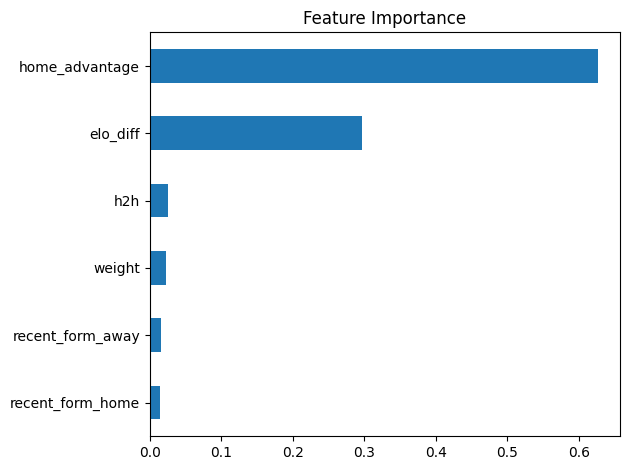

In [24]:
import matplotlib.pyplot as plt

feat_importance = pd.Series(xgb_model.feature_importances_, index=features)
feat_importance.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()